In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set up styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

In [40]:
df_hotspot = pd.read_csv("model_comparison_specific.csv")
df_metrics = pd.read_csv("model_comparison_generic.csv")

## Model Performance Comparison

This section visualizes and compares the performance of different models across multiple evaluation metrics.

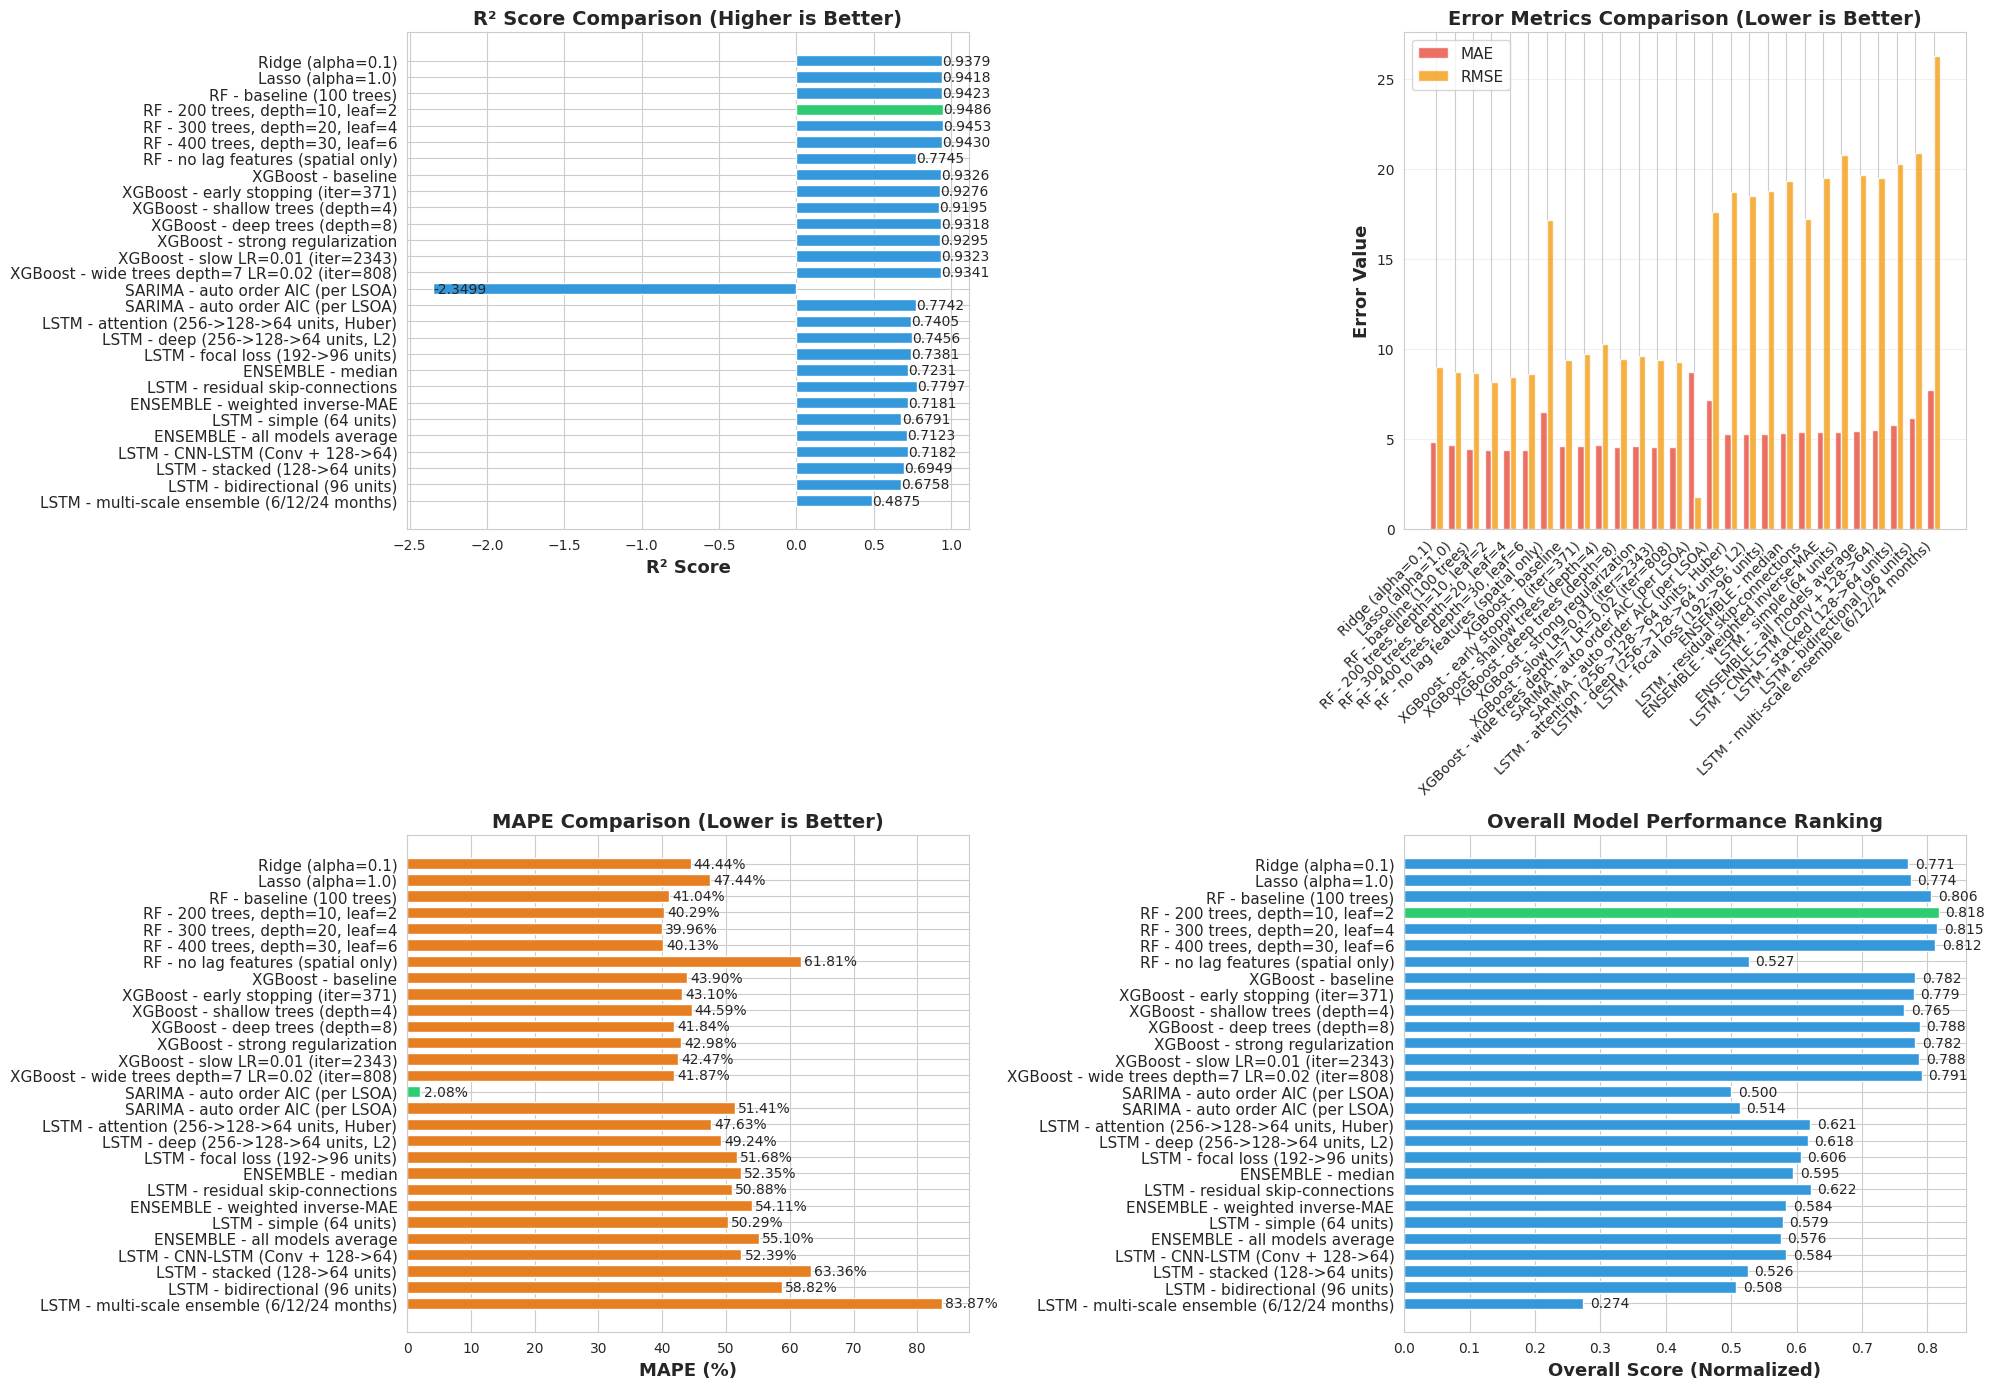

Best performing model:
  RF - 200 trees, depth=10, leaf=2 (Score: 0.8177)


In [41]:
# Clean up model names for better visualization
df_metrics['Model_Short'] = df_metrics['Model'].str.replace('"', '').str.replace(', no depth limit', '')

# Create a comprehensive comparison figure with larger size
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# 1. R² Score Comparison (higher is better)
ax1 = axes[0, 0]
colors = ['#2ecc71' if x == df_metrics['R2'].max() else '#3498db' for x in df_metrics['R2']]
ax1.barh(range(len(df_metrics)), df_metrics['R2'], color=colors, height=0.7)
ax1.set_yticks(range(len(df_metrics)))
ax1.set_yticklabels(df_metrics['Model_Short'], fontsize=11)
ax1.set_xlabel('R² Score', fontsize=13, fontweight='bold')
ax1.set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
for i, v in enumerate(df_metrics['R2']):
    ax1.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

# 2. Error Metrics (MAE and RMSE - lower is better)
ax2 = axes[0, 1]
x_pos = np.arange(len(df_metrics))
width = 0.35
ax2.bar(x_pos - width/2, df_metrics['MAE'], width, label='MAE', color='#e74c3c', alpha=0.8)
ax2.bar(x_pos + width/2, df_metrics['RMSE'], width, label='RMSE', color='#f39c12', alpha=0.8)
ax2.set_ylabel('Error Value', fontsize=13, fontweight='bold')
ax2.set_title('Error Metrics Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(df_metrics['Model_Short'], rotation=45, ha='right', fontsize=10)
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

# 3. MAPE Comparison
ax3 = axes[1, 0]
colors_mape = ['#2ecc71' if x == df_metrics['MAPE'].min() else '#e67e22' for x in df_metrics['MAPE']]
ax3.barh(range(len(df_metrics)), df_metrics['MAPE'], color=colors_mape, height=0.7)
ax3.set_yticks(range(len(df_metrics)))
ax3.set_yticklabels(df_metrics['Model_Short'], fontsize=11)
ax3.set_xlabel('MAPE (%)', fontsize=13, fontweight='bold')
ax3.set_title('MAPE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax3.invert_yaxis()
for i, v in enumerate(df_metrics['MAPE']):
    ax3.text(v + 0.5, i, f'{v:.2f}%', va='center', fontsize=10)

# 4. Overall Model Ranking (normalized scores)
ax4 = axes[1, 1]
# Normalize metrics to 0-1 scale where higher is better
mae_norm = 1 - (df_metrics['MAE'] - df_metrics['MAE'].min()) / (df_metrics['MAE'].max() - df_metrics['MAE'].min())
rmse_norm = 1 - (df_metrics['RMSE'] - df_metrics['RMSE'].min()) / (df_metrics['RMSE'].max() - df_metrics['RMSE'].min())
r2_norm = (df_metrics['R2'] - df_metrics['R2'].min()) / (df_metrics['R2'].max() - df_metrics['R2'].min())
mape_norm = 1 - (df_metrics['MAPE'] - df_metrics['MAPE'].min()) / (df_metrics['MAPE'].max() - df_metrics['MAPE'].min())

overall_score = (mae_norm + rmse_norm + r2_norm + mape_norm) / 4
colors_rank = ['#2ecc71' if i == overall_score.argmax() else '#3498db' for i in range(len(overall_score))]

ax4.barh(range(len(df_metrics)), overall_score, color=colors_rank, height=0.7)
ax4.set_yticks(range(len(df_metrics)))
ax4.set_yticklabels(df_metrics['Model_Short'], fontsize=11)
ax4.set_xlabel('Overall Score (Normalized)', fontsize=13, fontweight='bold')
ax4.set_title('Overall Model Performance Ranking', fontsize=14, fontweight='bold')
ax4.invert_yaxis()
for i, v in enumerate(overall_score):
    ax4.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("Best performing model:")
best_idx = overall_score.argmax()
print(f"  {df_metrics.iloc[best_idx]['Model']} (Score: {overall_score.iloc[best_idx]:.4f})")

## Metric Correlations and Feature Importance

Exploring relationships between different evaluation metrics to understand trade-offs.

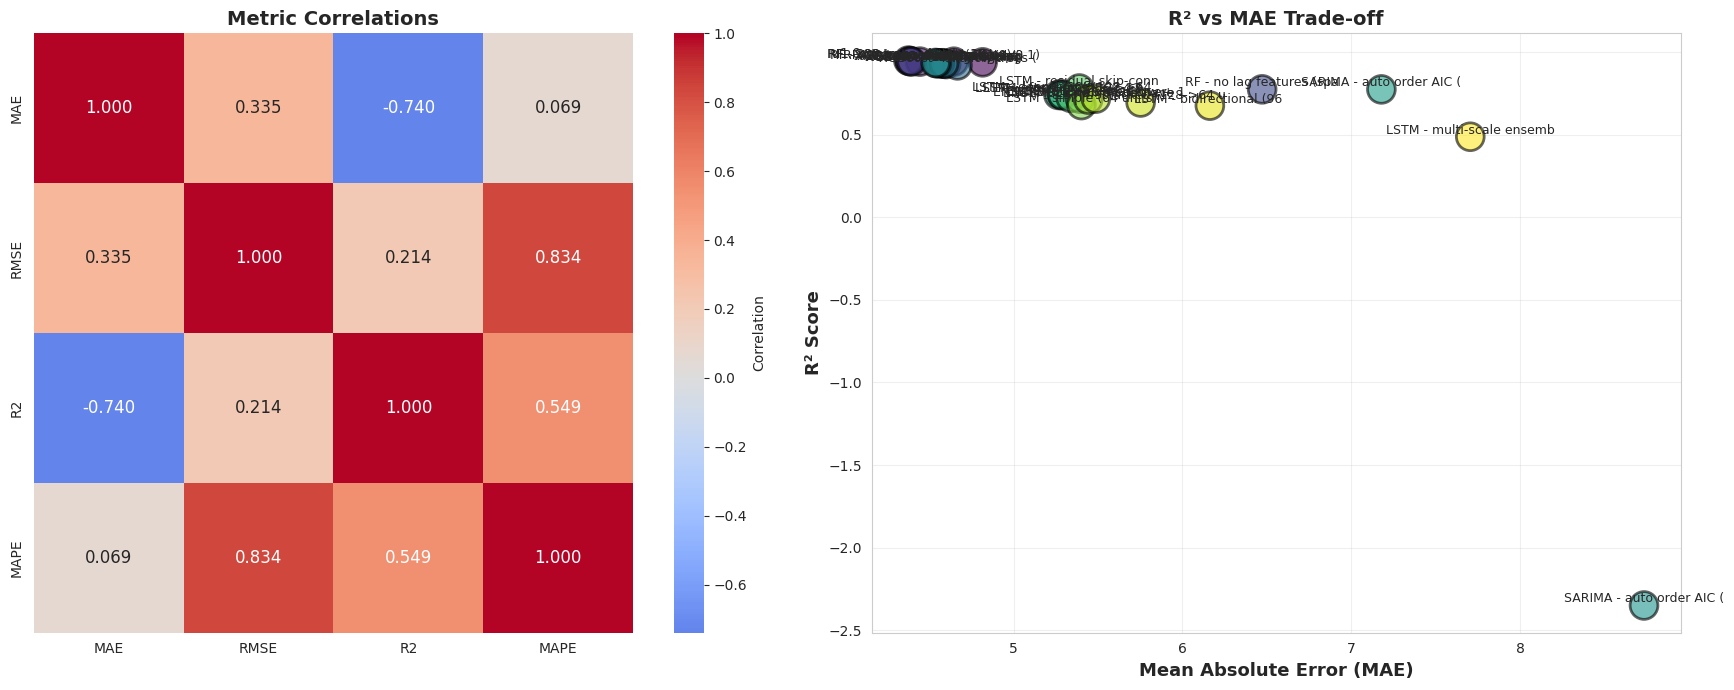


=== METRIC CORRELATION ANALYSIS ===

Correlation Matrix:
        MAE   RMSE     R2   MAPE
MAE   1.000  0.335 -0.740  0.069
RMSE  0.335  1.000  0.214  0.834
R2   -0.740  0.214  1.000  0.549
MAPE  0.069  0.834  0.549  1.000

Key Insights:
  • R² and MAE: -0.740 - Strong negative correlation
  • R² and RMSE: 0.214 - Strong negative correlation
  • MAE and RMSE: 0.335 - Very strong positive correlation


In [42]:
# Correlation analysis with larger figure
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Correlation Matrix Heatmap
ax1 = axes[0]
correlation_data = df_metrics[['MAE', 'RMSE', 'R2', 'MAPE']].corr()
sns.heatmap(correlation_data, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, ax=ax1, cbar_kws={'label': 'Correlation'}, annot_kws={'fontsize': 12})
ax1.set_title('Metric Correlations', fontsize=14, fontweight='bold')

# 2. R² vs MAE scatter plot
ax2 = axes[1]
scatter = ax2.scatter(df_metrics['MAE'], df_metrics['R2'], s=400, 
                      c=range(len(df_metrics)), cmap='viridis', alpha=0.6, edgecolors='black', linewidth=2)

# Add model labels
for idx, row in df_metrics.iterrows():
    model_label = row['Model'].replace('"', '')[:25]
    ax2.annotate(model_label, (row['MAE'], row['R2']), 
                fontsize=9, ha='center', va='bottom')

ax2.set_xlabel('Mean Absolute Error (MAE)', fontsize=13, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=13, fontweight='bold')
ax2.set_title('R² vs MAE Trade-off', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print correlation insights
print("\n=== METRIC CORRELATION ANALYSIS ===")
print("\nCorrelation Matrix:")
print(correlation_data.round(3))
print("\nKey Insights:")
print("  • R² and MAE:", f"{correlation_data.loc['R2', 'MAE']:.3f} - Strong negative correlation")
print("  • R² and RMSE:", f"{correlation_data.loc['R2', 'RMSE']:.3f} - Strong negative correlation")
print("  • MAE and RMSE:", f"{correlation_data.loc['MAE', 'RMSE']:.3f} - Very strong positive correlation")

## Hotspot Detection Analysis

Analysis of how effectively models identify crime hotspots at different coverage levels (5%, 10%, 20%).

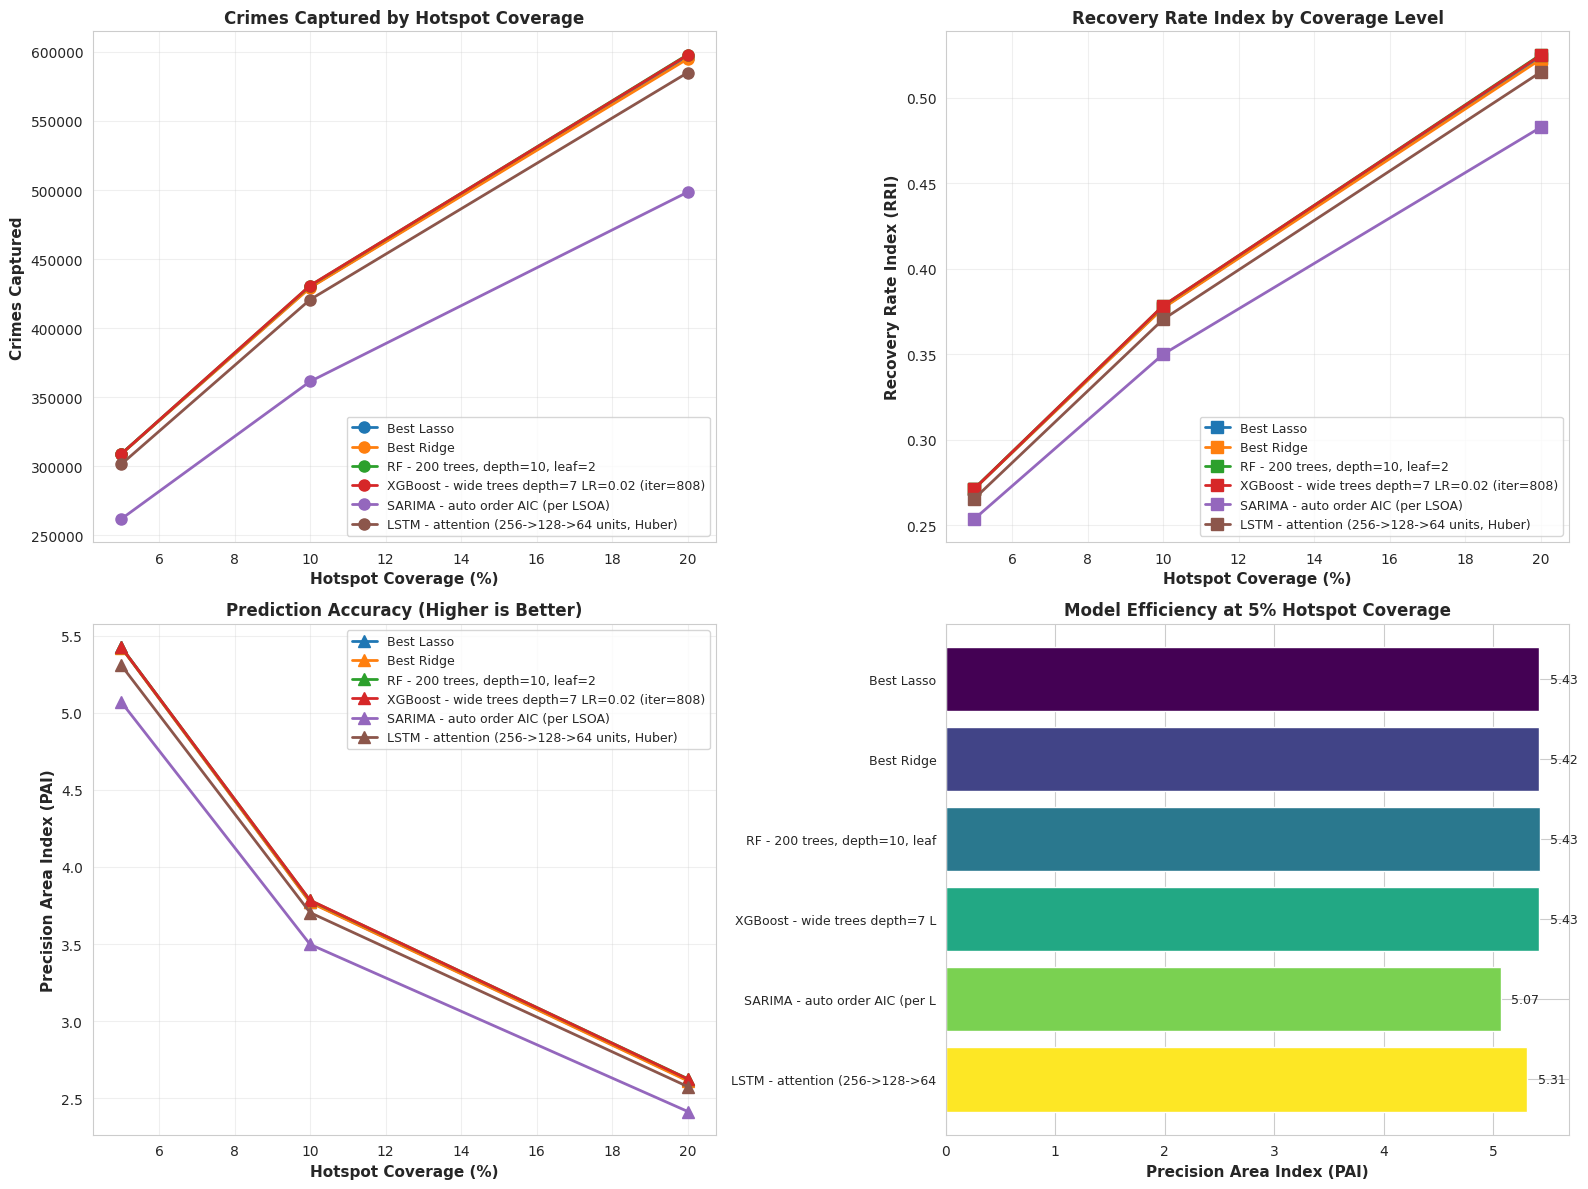


=== HOTSPOT DETECTION SUMMARY ===

At 5% Coverage:
  Best Model: RF - 200 trees, depth=10, leaf=2
  PAI Score: 5.4263
  Crimes Captured: 309,001 / 1,138,656

At 10% Coverage:
  Best Model: XGBoost - wide trees depth=7 LR=0.02 (iter=808)
  PAI Score: 3.7841
  Crimes Captured: 430,904 / 1,138,656

At 20% Coverage:
  Best Model: RF - 200 trees, depth=10, leaf=2
  PAI Score: 2.6261
  Crimes Captured: 598,082 / 1,138,656


In [43]:
# Extract unique models and hotspot percentages
df_hotspot['Model_Clean'] = df_hotspot['Model'].str.replace('"', '')
unique_models = df_hotspot['Model_Clean'].unique()
hotspot_percentages = sorted(df_hotspot['Hotspot_%'].unique())

# Create hotspot analysis visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Crimes Captured vs Hotspot Coverage
ax1 = axes[0, 0]
for model in unique_models:
    model_data = df_hotspot[df_hotspot['Model_Clean'] == model]
    ax1.plot(model_data['Hotspot_%'], model_data['Crimes_Captured'], 
             marker='o', label=model, linewidth=2, markersize=8)
ax1.set_xlabel('Hotspot Coverage (%)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Crimes Captured', fontsize=11, fontweight='bold')
ax1.set_title('Crimes Captured by Hotspot Coverage', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, alpha=0.3)

# 2. RRI (Recovery Rate Index) Comparison
ax2 = axes[0, 1]
for model in unique_models:
    model_data = df_hotspot[df_hotspot['Model_Clean'] == model]
    ax2.plot(model_data['Hotspot_%'], model_data['RRI'], 
             marker='s', label=model, linewidth=2, markersize=8)
ax2.set_xlabel('Hotspot Coverage (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Recovery Rate Index (RRI)', fontsize=11, fontweight='bold')
ax2.set_title('Recovery Rate Index by Coverage Level', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(True, alpha=0.3)

# 3. PAI (Precision Area Index) - Higher is better
ax3 = axes[1, 0]
for model in unique_models:
    model_data = df_hotspot[df_hotspot['Model_Clean'] == model]
    ax3.plot(model_data['Hotspot_%'], model_data['PAI'], 
             marker='^', label=model, linewidth=2, markersize=8)
ax3.set_xlabel('Hotspot Coverage (%)', fontsize=11, fontweight='bold')
ax3.set_ylabel('Precision Area Index (PAI)', fontsize=11, fontweight='bold')
ax3.set_title('Prediction Accuracy (Higher is Better)', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9, loc='upper right')
ax3.grid(True, alpha=0.3)

# 4. Model Efficiency at 5% Coverage (focusing on practical deployment)
ax4 = axes[1, 1]
coverage_5pct = df_hotspot[df_hotspot['Hotspot_%'] == 5].copy()
coverage_5pct['Model_Clean_Short'] = coverage_5pct['Model_Clean'].str[:30]
colors_eff = plt.cm.viridis(np.linspace(0, 1, len(coverage_5pct)))

bars = ax4.barh(range(len(coverage_5pct)), coverage_5pct['PAI'], color=colors_eff)
ax4.set_yticks(range(len(coverage_5pct)))
ax4.set_yticklabels(coverage_5pct['Model_Clean_Short'], fontsize=9)
ax4.set_xlabel('Precision Area Index (PAI)', fontsize=11, fontweight='bold')
ax4.set_title('Model Efficiency at 5% Hotspot Coverage', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

for i, (idx, row) in enumerate(coverage_5pct.iterrows()):
    ax4.text(row['PAI'] + 0.1, i, f"{row['PAI']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== HOTSPOT DETECTION SUMMARY ===")
for coverage in hotspot_percentages:
    coverage_data = df_hotspot[df_hotspot['Hotspot_%'] == coverage]
    best_pai = coverage_data.loc[coverage_data['PAI'].idxmax()]
    print(f"\nAt {coverage}% Coverage:")
    print(f"  Best Model: {best_pai['Model_Clean']}")
    print(f"  PAI Score: {best_pai['PAI']:.4f}")
    print(f"  Crimes Captured: {best_pai['Crimes_Captured']:,.0f} / {best_pai['Total_Crimes']:,.0f}")